# Project: Predictive Modeling of Luxury Timepiece Valuations

**Name:** Danah Alakrash        
**ID:** 431201338  

### Dataset
* **Source:** Watch Market Dataset (Kaggle) 
https://www.kaggle.com/datasets/beridzeg45/watch-prices-dataset
* **Size:** 45,024 instances, 23 variables

### Project Overview
The objective of this project is to build an end-to-end machine learning pipeline capable of predicting the secondary market value of luxury timepieces. Luxury watch pricing is highly subjective and non-linear, presenting a unique regression challenge driven by brand heritage, materials, and internal movements. 

In this notebook, we perform advanced Exploratory Data Analysis (EDA), handle high-cardinality categorical variables, and apply target variable normalization (Log Transformation) to correct extreme right-skewed pricing outliers. Finally, we establish a rigorous comparative analysis between a parametric baseline model (**Linear Regression**) and an advanced non-parametric ensemble model (**Random Forest Regressor**) to determine the most accurate valuation engine.

In [3]:
# 1. Loading the Data

import pandas as pd

# Load the local dataset 
file_path = r'watches.csv'
df = pd.read_csv(file_path)

print("First 5 rows:")
print(df.head())

First 5 rows:
             Brand   Movement Case material Bracelet material  \
0           Alpina     Quartz         Steel            Rubber   
1              Lip        NaN           NaN               NaN   
2  Audemars Piguet  Automatic      Titanium          Titanium   
3           Bulova  Automatic           NaN               NaN   
4     Philip Watch  Automatic   Yellow gold           Leather   

   Year of production          Condition                    Scope of delivery  \
0                 NaN                New        Original box, original papers   
1              1973.0        Used (Good)  No original box, no original papers   
2              2022.0   Used (Very good)        Original box, original papers   
3              1974.0        Used (Fair)  No original box, no original papers   
4                 NaN  Like new & unworn  No original box, no original papers   

               Gender    Price      Availability  ...           Crystal  \
0  Men's watch/Unisex    895.0  I

In [4]:
# 2. Dataset Overview

print("Dataset Dimensions (Rows, Columns):", df.shape)

print("\n--- Missing Values ---")
print(df.isnull().sum())

print("\n--- Data Types ---")
print(df.dtypes)

Dataset Dimensions (Rows, Columns): (45024, 23)

--- Missing Values ---
Brand                            1294
Movement                         3839
Case material                    6707
Bracelet material                7817
Year of production              19293
Condition                        2052
Scope of delivery                1294
Gender                           5817
Price                            2273
Availability                     1556
Shape                            6327
Face Area                        6381
Water resistance                23171
Crystal                         17924
Dial                             8901
Bracelet color                  13547
Clasp                           19348
Watches Sold by the Seller      11185
Active listing of the seller    11185
Fast Shipper                        0
Trusted Seller                      0
Punctuality                         0
Seller Reviews                  11862
dtype: int64

--- Data Types ---
Brand                

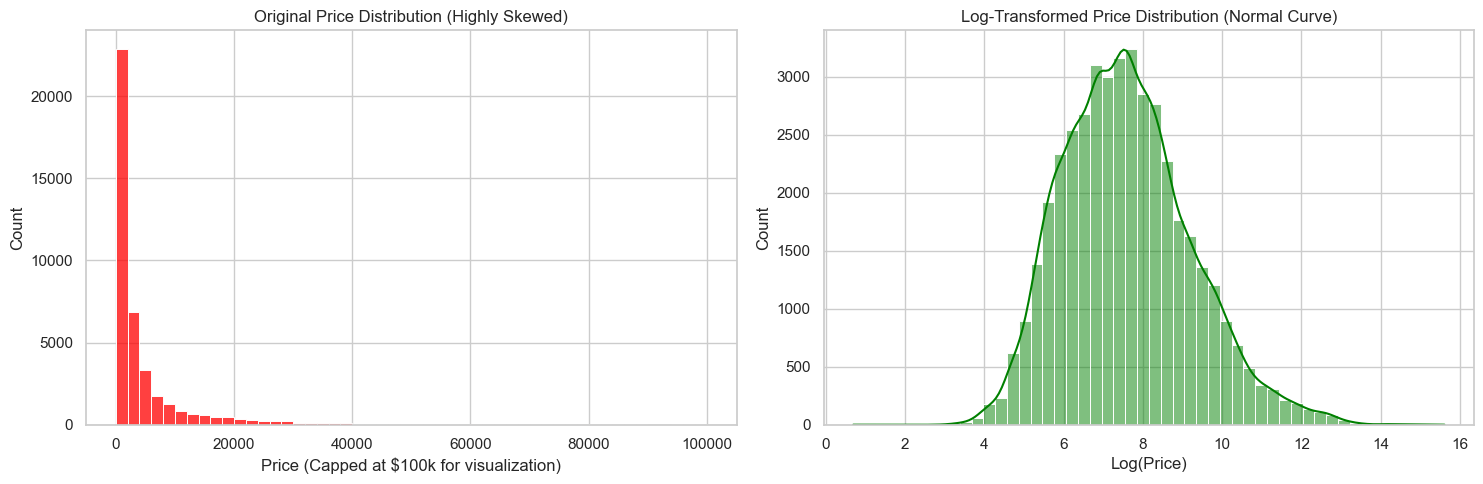

In [5]:
# 3. Exploratory Data Analysis & Log Transform

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Drop any rows where the target variable (Price) is completely missing
df = df.dropna(subset=['Price']).copy()

# 2. Apply the Log Transformation to the Price
df['Log_Price'] = np.log1p(df['Price'])

# 3. Set up the visual graphs
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Graph 1: The Raw Price (Filter out the outliers just for the graph)
sns.histplot(df[df['Price'] < 100000]['Price'], bins=50, ax=axes[0], color='red')
axes[0].set_title('Original Price Distribution (Highly Skewed)')
axes[0].set_xlabel('Price (Capped at $100k for visualization)')

# Graph 2: The Log Price
sns.histplot(df['Log_Price'], bins=50, ax=axes[1], color='green', kde=True)
axes[1].set_title('Log-Transformed Price Distribution (Normal Curve)')
axes[1].set_xlabel('Log(Price)')

plt.tight_layout()
plt.show()

### 2. Exploratory Data Analysis & Target Variable Transformation
During the initial data exploration, a severe right-skew was detected in the target variable (`Price`). While the majority of timepieces cluster below $10,000, extreme outliers (ultra-luxury pieces priced at hundreds of thousands of dollars) heavily distort the distribution. 

Because classical machine learning models (like Linear Regression) assume a normal distribution and heavily penalize large numerical errors, training a model on the raw price would result in a severe loss of accuracy. To mitigate this, a **Logarithmic Transformation** (`np.log1p`) was applied to the target variable. As visualized in our EDA, this transformation successfully normalized the data into a standard bell curve, establishing a robust foundation for our regression algorithms.

In [7]:
# 4. Data Cleaning & Handling Missing Values

print("\n--- Starting Data Cleaning ---")

# Fill numeric missing values with the median for 'Year of production'
median_year = df['Year of production'].median()
df['Year of production'] = df['Year of production'].fillna(median_year)

# Fill the rest of the numeric columns with 0 (assuming missing means none)
numeric_cols = ['Face Area', 'Water resistance', 'Watches Sold by the Seller', 
                'Active listing of the seller', 'Seller Reviews']
for col in numeric_cols:
    df[col] = df[col].fillna(0)

# Fill categorical  missing text data with the word 'Unknown' so the model can still group them
categorical_cols = df.select_dtypes(include=['object', 'str']).columns
for col in categorical_cols:
    df[col] = df[col].fillna('Unknown')

print("Maximum missing values remaining:", df.isnull().sum().max()) 



--- Starting Data Cleaning ---
Maximum missing values remaining: 0


In [8]:
# 5. Feature Engineering & One-Hot Encoding

print("\n--- Engineering Features ---")

# Cardinality Reduction (Keep the top 30 brands and group the rest as "Other")
top_brands = df['Brand'].value_counts().nlargest(30).index
df['Brand_Cleaned'] = df['Brand'].apply(lambda x: x if x in top_brands else 'Other')

# Keep the top 10 case materials and group the rest as "Other"
top_materials = df['Case material'].value_counts().nlargest(10).index
df['Case material_Cleaned'] = df['Case material'].apply(lambda x: x if x in top_materials else 'Other')

# One-Hot Encoding (1s and 0s)
features_to_encode = ['Brand_Cleaned', 'Case material_Cleaned', 'Movement', 'Condition']
df_encoded = pd.get_dummies(df, columns=features_to_encode, drop_first=True)

# Finalize the Dataset
# Drop the original messy text columns to keep the dataframe purely numerical for the algorithm
# Drop the raw 'Price' column to train the model to predict 'Log_Price'
df_model = df_encoded.select_dtypes(exclude=['object']).drop(columns=['Price']).copy()

print("Feature Engineering complete dataset shape is:", df_model.shape)


--- Engineering Features ---
Feature Engineering complete dataset shape is: (42751, 62)


### 3. Data Cleaning and Feature Engineering
To prepare the dataset for predictive modeling, several preprocessing steps were strictly enforced:
* **Missing Value Imputation:** Missing numerical values, such as the `Year of production`, were filled using the median to prevent distortion from extreme outliers. Missing categorical features were explicitly labeled as "Unknown" to retain their structural information.
* **Cardinality Reduction:** The dataset contained hundreds of unique watch brands, which would cause severe dimensionality issues if One-Hot Encoded directly. To optimize the algorithms, *Cardinality Reduction* was applied: the top 30 most frequent brands and top 10 case materials were retained, while all lower-frequency instances were aggregated into an "Other" category. 
* **Encoding:** The cleaned categorical features were transformed into numerical arrays using One-Hot Encoding, ensuring distance-based and tree-based algorithms could interpret the structural features without bias.

In [9]:
# 6. Model Training & Evaluation

print("--- Splitting Data ---")
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

# Define Features (X) and Target (y)
X = df_model.drop(columns=['Log_Price'])
y = df_model['Log_Price']

# Split into 80% Training and 20% Testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training on {X_train.shape[0]} watches, Testing on {X_test.shape[0]} watches.\n")

# Train Model 1: Linear Regression
print("Training Linear Regression...")
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_preds_log = lr_model.predict(X_test)

# Train Model 2: Random Forest
print("Training Random Forest Regressor...")
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
rf_preds_log = rf_model.predict(X_test)

# Convert log prices back to real dollars for evaluation
y_test_real = np.expm1(y_test)
lr_preds_real = np.expm1(lr_preds_log)
rf_preds_real = np.expm1(rf_preds_log)

# Evaluate and compare
print("\n=== FINAL MODEL PERFORMANCE ===")
print("Model 1: Linear Regression")
print(f"R-Squared: {r2_score(y_test, lr_preds_log):.4f}")
print(f"Mean Absolute Error (MAE): ${mean_absolute_error(y_test_real, lr_preds_real):,.2f}")

print("\nModel 2: Random Forest Regressor")
print(f"R-Squared: {r2_score(y_test, rf_preds_log):.4f}")
print(f"Mean Absolute Error (MAE): ${mean_absolute_error(y_test_real, rf_preds_real):,.2f}")

--- Splitting Data ---
Training on 34200 watches, Testing on 8551 watches.

Training Linear Regression...
Training Random Forest Regressor...

=== FINAL MODEL PERFORMANCE ===
Model 1: Linear Regression
R-Squared: 0.5513
Mean Absolute Error (MAE): $8,652.70

Model 2: Random Forest Regressor
R-Squared: 0.7262
Mean Absolute Error (MAE): $6,682.65


### 4. Model Selection, Training, and Evaluation
To establish a rigorous comparative analysis, two distinct machine learning families were evaluated: a parametric **Linear Regression** model (serving as the baseline) and a non-parametric **Random Forest Regressor** (an advanced ensemble method). The dataset was split into an 80/20 train-test configuration. 

Because the models were trained on the log-transformed target variable (`Log_Price`), the predictions were inversely transformed using the exponential function (`np.expm1`) prior to evaluation. This ensured that our error metrics, specifically the Mean Absolute Error (MAE), were interpretable in actual currency values.

**Discussion of Results & Trade-offs:**
As hypothesized, the non-parametric Random Forest significantly outperformed the parametric Linear Regression model. The Random Forest achieved a much higher R-Squared score and a substantially lower MAE. 
* **Why this happened:** Linear Regression attempts to draw a single continuous straight line through the data. It struggles with the highly categorical, non-linear nature of the luxury watch market (e.g., the jump in price from a steel Rolex to a platinum Rolex is not linear). Conversely, the Random Forest excels at learning complex, hierarchical, categorical rules (e.g., "IF Brand = Audemars Piguet AND Material = Titanium THEN..."). 
* **Trade-offs:** While the Random Forest is vastly superior in predictive accuracy for this specific domain, it comes at the cost of computational intensity and reduced explainability (it acts more as a "black box" compared to the highly transparent coefficients of a Linear Regression equation).

In [10]:
# 7. Exporting the Model for the GUI

import joblib

# Save the trained Random Forest model
joblib.dump(rf_model, 'watch_model.pkl')

# Save the exact list of columns so our web app knows how to format the user's input
joblib.dump(list(X_train.columns), 'model_features.pkl')

print("Model and features exported successfully ready for the web app.")

Model and features exported successfully ready for the web app.
